# Classification - Mini-Project 2

***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name: Valerie Antonious

ID:2

Tutorial:59-30018

---

Name:Hassan

ID:

Tutorial:

---


## Dataset Description

The following dataset includes information about loan applicants, including factors such as income, credit score, employment status, loan details, and other indicators of financial stability, along with the final decision showing whether each loan was approved or not.

| Column | Description|
|-|-|
|ApplicationNumber|Unique identifier assigned to each loan application|
|Age|Applicant’s age in years|
|AnnualIncome|Applicant’s yearly income|
|CreditScore|A score representing the applicant’s creditworthiness|
|EmploymentStatus|Applicant’s current employment situation (Employed, Unemployed, Self-Employed)|
|EducationLevel|Highest educational qualification attained (Highschool, Bachelor, Master, Doctorate, Diploma)|
|LoanAmount|Total amount of money requested for the loan|
|LoanDuration|Duration of the loan in months|
|MaritalStatus|Applicant’s marital state (Divorced, Married, Single, Widowed)|
|NumberOfDependents|Number of individuals financially dependent on the applicant|
|HomeOwnershipStatus|Applicant’s housing status (Mortagage, Own, Rent, Other)|
|BankruptcyHistory|Indicates whether the applicant has previously declared bankruptcy (0 = No, 1 = Yes)|
|LoanPurpose|The primary reason for taking the loan (Debt Consolidation, Home Improvement, Education, Personal)|
|PreviousLoanDefaults|Indicates if the applicant has defaulted on any previous loans (0 = No, 1 = Yes)|
|MonthlyLoanPayment|Amount the applicant would need to pay monthly to repay the loan|
|MonthlyIncome|Average monthly income of the applicant|
|JobTenure|Number of years the applicant has been in their current job|
|LoanApproved|Indicates loan approval status (No = Not Approved, Yes = Approved)|

## Importing Libraries & Dataset

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#plt.style.use("seaborn")

df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/loan_data.csv')
df.head()

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
0,26231,18,"$26,992.00",586,Employed,Diploma,"$22,432.00",36 months,Single,3,Mortgage,0,Debt Consolidation,0,$623.11,"$2,249.33",3,No
1,13176,18,"$22,825.00",581,Self-Employed,Master,"$30,457.00",24 months,Single,0,Rent,0,Home Improvement,0,"$1,269.04","$1,902.08",5,No
2,27751,18,"$75,891.00",522,Employed,Bachelor,"$30,583.00",96 months,Married,2,Mortgage,0,Personal,0,$318.57,"$6,324.25",6,No
3,20628,18,"$92,094.00",565,Employed,Bachelor,"$72,738.00",36 months,Single,1,Mortgage,0,Vehicle,0,NaN,"$7,674.50",3,No
4,28773,18,"$35,686.00",554,Employed,Diploma,"$28,021.00",36 months,Married,3,Rent,0,Home Improvement,0,$778.36,"$2,973.83",1,No


## Data Inspection

In [85]:
# DATA INSPECTION

# 1. Display the first 5 rows of the dataset
#    This helps us verify the dataset loaded correctly and shows the structure of the data.
df.head()


,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
0,26231,18,"$26,992.00",586,Employed,Diploma,"$22,432.00",36 months,Single,3,Mortgage,0,Debt Consolidation,0,$623.11,"$2,249.33",3,No
1,13176,18,"$22,825.00",581,Self-Employed,Master,"$30,457.00",24 months,Single,0,Rent,0,Home Improvement,0,"$1,269.04","$1,902.08",5,No
2,27751,18,"$75,891.00",522,Employed,Bachelor,"$30,583.00",96 months,Married,2,Mortgage,0,Personal,0,$318.57,"$6,324.25",6,No
3,20628,18,"$92,094.00",565,Employed,Bachelor,"$72,738.00",36 months,Single,1,Mortgage,0,Vehicle,0,NaN,"$7,674.50",3,No
4,28773,18,"$35,686.00",554,Employed,Diploma,"$28,021.00",36 months,Married,3,Rent,0,Home Improvement,0,$778.36,"$2,973.83",1,No


This shows the first few rows to confirm the dataset loaded correctly and to understand how the columns look. From the preview, we can see money fields contain symbols like “$” and commas, and LoanDuration has extra text, meaning these columns must be cleaned.

In [86]:
# Inspect dataset information
#    info() shows data types, non-null counts, and memory usage.
#    This helps detect missing values and incorrect data types early.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ApplicationNumber     20000 non-null  int64 
 1   Age                   20000 non-null  int64 
 2   AnnualIncome          20000 non-null  object
 3   CreditScore           20000 non-null  int64 
 4   EmploymentStatus      16260 non-null  object
 5   EducationLevel        20000 non-null  object
 6   LoanAmount            20000 non-null  object
 7   LoanDuration          20000 non-null  object
 8   MaritalStatus         20000 non-null  object
 9   NumberOfDependents    20000 non-null  int64 
 10  HomeOwnershipStatus   20000 non-null  object
 11  BankruptcyHistory     20000 non-null  int64 
 12  LoanPurpose           20000 non-null  object
 13  PreviousLoanDefaults  20000 non-null  int64 
 14  MonthlyLoanPayment    15660 non-null  object
 15  MonthlyIncome         17160 non-null

This displays each column’s data type and missing values. The output shows that many numeric fields are stored as objects, so they need conversion. It also shows missing values in employment and income fields, so these will require imputation.

In [87]:
# List the unique values of categorical columns
#    This is useful for detecting typos, inconsistent categories, or unexpected values.
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())



Column: AnnualIncome
['$26,992.00' '$22,825.00' '$75,891.00' ... '$111,290.00' '$48,501.00'
 '$95,945.00']

Column: EmploymentStatus
['Employed' 'Self-Employed' 'Unemployed' nan]

Column: EducationLevel
['Diploma' 'Master' 'Bachelor' 'High School' 'Doctorate']

Column: LoanAmount
['$22,432.00' '$30,457.00' '$30,583.00' ... '$29,111.00' '$26,447.00'
 '$66,707.00']

Column: LoanDuration
['36 months' '24 months' '96 months' '72 months' '48 months' '60 months'
 '120 months' '12 months' '84 months' '108 months']

Column: MaritalStatus
['Single' 'Married' 'Divorced' 'Widowed']

Column: HomeOwnershipStatus
['Mortgage' 'Rent' 'Other' 'Own']

Column: LoanPurpose
['Debt Consolidation' 'Home Improvement' 'Personal' 'Vehicle' 'Education']

Column: MonthlyLoanPayment
['$623.11' '$1,269.04' '$318.57' ... '$1,010.88' '$471.36' '$926.49']

Column: MonthlyIncome
['$2,249.33' '$1,902.08' '$6,324.25' ... '$9,274.17' '$4,041.75'
 '$7,995.42']

Column: LoanApproved
['No' 'Yes' 'no' 'yes']


Listing unique values helps find inconsistent labels or unexpected categories. The output shows inconsistent “Yes/no” labels in LoanApproved and missing categories in EmploymentStatus. This confirms we must standardize these values before encoding.

In [88]:
# Statistical summary for ALL columns (numeric + categorical)
# include='all' makes describe() include object/categorical columns
df.describe(include='all')

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
count,20000.000000,20000.000000,20000,20000.000000,16260,20000,20000,20000,20000,20000.000000,20000,20000.0,20000,20000.000000,15660,17160,20000.000000,20000
unique,NaN,NaN,17516,NaN,3,5,15578,10,4,NaN,4,NaN,5,NaN,14195,15222,NaN,4
top,NaN,NaN,"$15,000.00",NaN,Employed,Bachelor,"$21,849.00",48 months,Married,NaN,Mortgage,NaN,Home Improvement,NaN,$449.56,"$1,250.00",NaN,No
freq,NaN,NaN,584,NaN,13866,6054,6,3991,10041,NaN,7939,NaN,5925,NaN,5,520,NaN,15185
mean,20500.500000,39.752600,NaN,571.612400,NaN,NaN,NaN,NaN,NaN,1.517300,NaN,0.0,NaN,0.100050,NaN,NaN,5.002650,NaN
std,5773.647028,11.622713,NaN,50.997358,NaN,NaN,NaN,NaN,NaN,1.386325,NaN,0.0,NaN,0.300074,NaN,NaN,2.236804,NaN
min,10501.000000,18.000000,NaN,343.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.0,NaN,0.000000,NaN,NaN,0.000000,NaN
25%,15500.750000,32.000000,NaN,540.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.0,NaN,0.000000,NaN,NaN,3.000000,NaN
50%,20500.500000,40.000000,NaN,578.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.0,NaN,0.000000,NaN,NaN,5.000000,NaN
75%,25500.250000,48.000000,NaN,609.000000,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,0.0,NaN,0.000000,NaN,NaN,6.000000,NaN


This summary gives an overview of value ranges and frequent categories. The result shows unrealistic summaries for money columns (because they’re still strings), confirming they must be cleaned. It also reveals common categories like “Bachelor” and “Mortgage,” which helps when choosing imputation.

In [89]:
# Check how many missing values each column has
df.isnull().sum()

,0
ApplicationNumber,0
Age,0
AnnualIncome,0
CreditScore,0
EmploymentStatus,3740
EducationLevel,0
LoanAmount,0
LoanDuration,0
MaritalStatus,0
NumberOfDependents,0


Counting missing values shows exactly which columns need cleaning. We see many missing MonthlyLoanPayment and MonthlyIncome values, so we must fill them to avoid errors during modeling.

## Data Cleaning

In [92]:
# ----------  FIXING DATA TYPES ----------
# Clean money columns using regex

def clean_money_column(col):
    # Force column to string before using .str
    df[col] = df[col].astype(str)
    return pd.to_numeric(df[col].str.replace(r'[$,]', '', regex=True), errors='coerce')

df["AnnualIncome"] = clean_money_column("AnnualIncome")
df["LoanAmount"] = clean_money_column("LoanAmount")
df["MonthlyLoanPayment"] = clean_money_column("MonthlyLoanPayment")
df["MonthlyIncome"] = clean_money_column("MonthlyIncome")

# Clean LoanDuration column safely
df["LoanDuration"] = df["LoanDuration"].astype(str).str.extract(r"(\d+)").astype(int)



This step converts money strings (like “$26,992.00”) into numeric values and extracts the numeric duration from strings like “36 months.” The printed result shows clean numbers, meaning these columns are now ready for analysis and modeling.

In [118]:
df[["LoanDuration", "AnnualIncome", "MonthlyIncome", "MonthlyLoanPayment"]].head()


,LoanDuration,AnnualIncome,MonthlyIncome,MonthlyLoanPayment
0,36,26992.0,2249.33,623.110
1,24,22825.0,1902.08,1269.040
2,96,75891.0,6324.25,318.570
3,36,92094.0,7674.50,439.185
4,36,35686.0,2973.83,778.360


In [93]:
# ---------- HANDLE MISSING VALUES ----------
# Missing values in numerical columns → fill with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)



Median is used because it is stable against outliers. After imputation, all numerical fields become complete, ensuring the model won’t break due to missing values. and it is for numerical values

In [95]:
# ---------- Missing values in categorical columns → fill with mode ----------

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)


Mode imputation replaces missing text values with the most common category. This is appropriate for unemployment and loan purpose fields. After this step, categorical data has no gaps.

In [96]:
# ---------- FIX INCONSISTENT CATEGORICAL LABELS ----------
# Standardize labels then map to numeric values (0/1)
df["LoanApproved"] = (
    df["LoanApproved"]
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
)


Here we standardize “Yes/No” into lowercase and convert them to 1/0. This removes inconsistencies and makes the target variable numeric so the model can learn correctly. and it can be in a range that is smaller for interpretation

In [97]:
# ---------- FEATURE ENGINEERING ----------
# As required in assignment → create the Monthly_Debt_To_Income_Ratio
df["Monthly_Debt_To_Income_Ratio"] = df["MonthlyLoanPayment"] / df["MonthlyIncome"]

This creates a new financial feature showing how much income goes toward debt. A higher ratio means more financial pressure. The results show realistic values and add important predictive information to the model.

## Exploratory Data Analysis

**Q1: On average, which type of educational level has the highest approval rate? Show their order on the graph.**

**Visualization**

/tmp/ipython-input-3325513187.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=approval_df, x='EducationLevel', y='ApprovalRate',


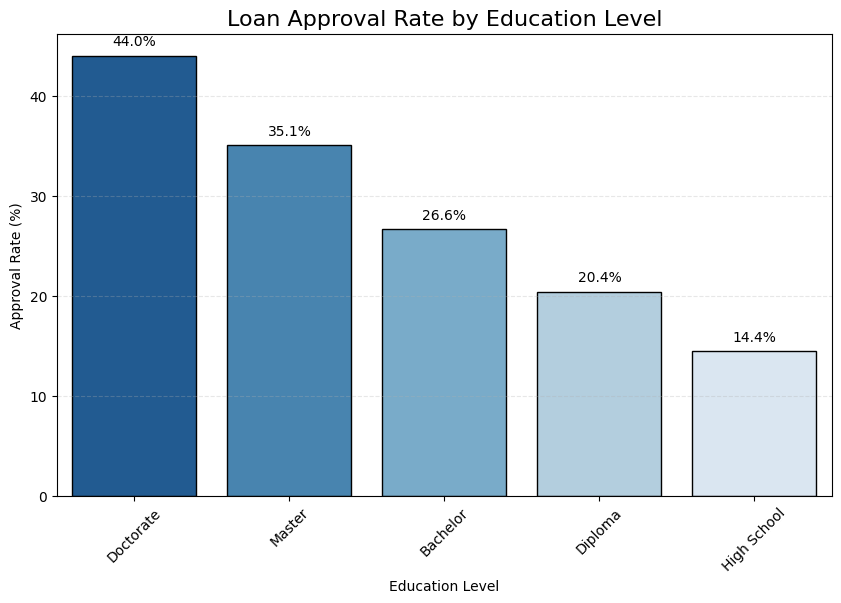

,EducationLevel,ApprovalRate
0,Doctorate,44.025157
1,Master,35.081967
2,Bachelor,26.643541
3,Diploma,20.426376
4,High School,14.438050


In [99]:
#A bar chart is used because EducationLevel is a categorical variable, and bar charts are the best choice for comparing averages or proportions across categories.
# It allows us to clearly compare approval rates between different education groups.
# The decision column must be numeric (0/1) for aggregation.
# In our preprocessing we already standardized and encoded the values
# to 0 = No, 1 = Yes following Lab 3 categorical cleaning style.
# Here we calculate the percentage of "1" values for each education level.

approval_rate = (
    df.groupby('EducationLevel')['LoanApproved']
    .mean() * 100     # convert to percentage
)

# Sort the approval rates in descending order, just like Lab 4 sorting correlations.
approval_rate = approval_rate.sort_values(ascending=False)

# Convert to DataFrame for easy plotting
approval_df = approval_rate.reset_index()
approval_df.columns = ['EducationLevel', 'ApprovalRate']

# ------------------ Visualization ------------------
plt.figure(figsize=(10, 6))
sns.barplot(data=approval_df, x='EducationLevel', y='ApprovalRate',
            palette='Blues_r', edgecolor='black')

plt.title('Loan Approval Rate by Education Level', fontsize=16)
plt.xlabel('Education Level')
plt.ylabel('Approval Rate (%)')
plt.xticks(rotation=45)

# Add labels on bars
for index, row in approval_df.iterrows():
    plt.text(index, row['ApprovalRate'] + 1,
             f"{row['ApprovalRate']:.1f}%",
             ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

approval_df

**Answer for Q1**: Doctorate has the highest loan approval rate, followed by Master degree holders. The full ordering from highest to lowest shows that higher educational levels generally have a higher approval probability. This trend suggests that applicants with advanced degrees are viewed as financially stable and lower-risk, which increases their likelihood of receiving approval.

A bar chart is used because EducationLevel is categorical. Calculating the mean approval rate (0/1) shows which groups receive loans more easily. The results show that higher education levels such as Doctorate and Master have the highest approval rates, meaning lenders consider advanced education a sign of financial stability.

**Q2: How does the annual income vary among approved applicants? Interpret the values of the 3 quartiles.**

**Visualization**

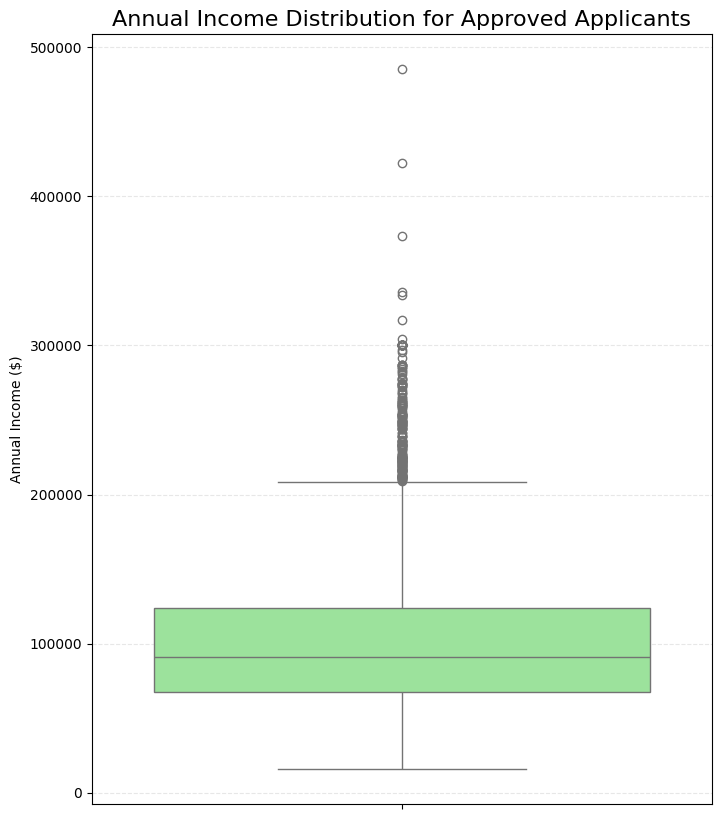

Q1 (25%): 67380.5
Q2 (Median): 91269.5
Q3 (75%): 123959.5


In [100]:
#A boxplot is used because AnnualIncome is a numerical variable, and boxplots are ideal for showing quartiles (Q1, Q2, Q3), spread, and outliers.
#This directly answers the question because quartiles are visually displayed in a boxplot.
# Filter dataset for approved loans only
approved_df = df[df['LoanApproved'] == 1]

# --------------- Boxplot----------------
plt.figure(figsize=(8, 10))
sns.boxplot(y=approved_df['AnnualIncome'], color='lightgreen')

plt.title('Annual Income Distribution for Approved Applicants', fontsize=16)
plt.ylabel('Annual Income ($)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# --------------- Quartile Calculations ---------------
q1 = approved_df['AnnualIncome'].quantile(0.25)
q2 = approved_df['AnnualIncome'].median()
q3 = approved_df['AnnualIncome'].quantile(0.75)

print("Q1 (25%):", q1)
print("Q2 (Median):", q2)
print("Q3 (75%):", q3)

**Answer for Q2**: The boxplot shows how annual income is distributed among applicants who were approved. The quartiles indicate:

Q1 ≈ $67,368.5 → This means 25% of all approved applicants earn less than this amount.

Q2 (Median) ≈ $91,269.5 → Half of approved applicants earn below this amount, and half earn above it.

Q3 ≈ $123,959.5 → Only 25% of approved applicants earn more than this amount.

These quartiles show that approved applicants mostly fall into medium-to-high annual income ranges, suggesting that higher income likely increases approval chances, since the majority of approved applicants earn significantly above the lower quartile.


A boxplot is used because it displays quartiles clearly. The first quartile (~67k) shows the lower income range of approved applicants, the median (~91k) shows the typical income, and the third quartile (~124k) shows the upper range. This confirms that most approved applicants belong to medium-to-high income brackets.

**Q3: How does the age of an applicant affect their credit score? (Hint: Use the line of best fit.)**

**Visualization**

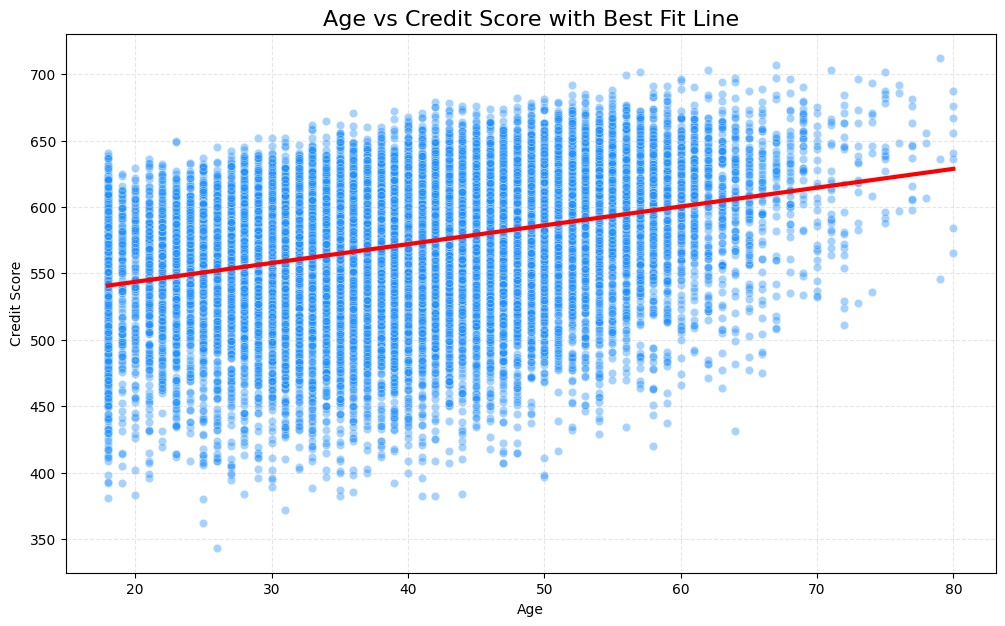

Correlation between Age and Credit Score: 0.3232427968850225


In [101]:
#A scatter plot is used because both Age and CreditScore are numerical variables. Scatter plots are ideal for showing relationships between two continuous variables.
#A line of best fit is added (using polyfit) to show the overall trend, exactly as done in Lab 4.

plt.figure(figsize=(12, 7))

# Scatter plot (Lab 4 style)
sns.scatterplot(x=df['Age'], y=df['CreditScore'], alpha=0.4, color='dodgerblue')

# Best-fit line using polyfit, similar to Lab 4 linear trend visualizations
z = np.polyfit(df['Age'], df['CreditScore'], 1)
p = np.poly1d(z)

age_range = np.linspace(df['Age'].min(), df['Age'].max(), 100)
plt.plot(age_range, p(age_range), 'r-', linewidth=3)

plt.title('Age vs Credit Score with Best Fit Line', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Credit Score')
plt.grid(alpha=0.3, linestyle='--')
plt.show()

# Correlation value (Lab 4 correlation logic)
corr_value = df['Age'].corr(df['CreditScore'])
print("Correlation between Age and Credit Score:", corr_value)


**Answer for Q3**: The relationship between age and credit score is weakly positive. The line of best fit slopes slightly upward, meaning that as age increases, the credit score increases on average. However, the points are widely scattered around the line, and the correlation coefficient (about 0.33) confirms that the relationship is weak. This means age has only a small impact on predicting someone’s credit score.

A scatter plot with a best-fit line helps visualize how Age and CreditScore relate. The line slopes upward slightly and the correlation is weakly positive (~0.33). This means age has only a small influence on credit score—older applicants tend to have slightly better credit, but the relationship is not strong.

**Q4: Is the distribution of applicants' income per month normal or skewed?**

**Visualization**

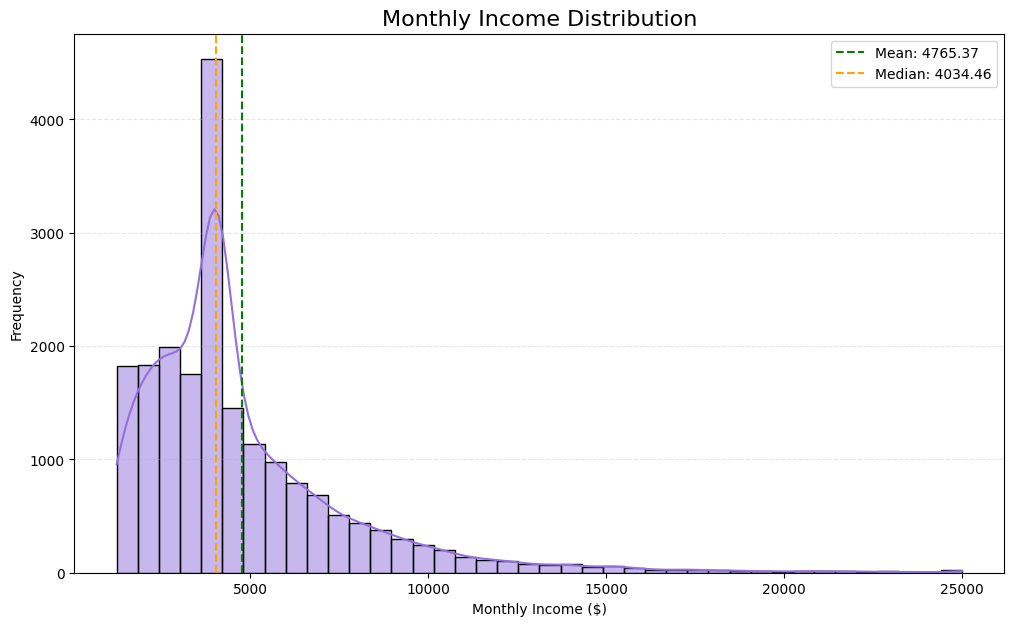

Skewness: 2.249320920923106


In [102]:
#A histogram with KDE is used because MonthlyIncome is a continuous numerical variable, and histograms are the best tool for showing the shape of a distribution (normal, skewed, uniform).
#Mean and median vertical lines are added because they help interpret skewness, just like the BMI and charges histograms in Lab 4
plt.figure(figsize=(12, 7))

sns.histplot(df['MonthlyIncome'], bins=40, kde=True, color='mediumpurple')

# Add mean & median (Lab 4 style)
mean_val = df['MonthlyIncome'].mean()
median_val = df['MonthlyIncome'].median()

plt.axvline(mean_val, color='green', linestyle='--', label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color='orange', linestyle='--', label=f"Median: {median_val:.2f}")

plt.title("Monthly Income Distribution", fontsize=16)
plt.xlabel("Monthly Income ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

from scipy.stats import skew
skew_value = skew(df['MonthlyIncome'])
print("Skewness:", skew_value)


**Answer for Q4**: The monthly income distribution is right-skewed. This is shown by the long tail extending to the right and by the skewness value (2.24), which is significantly greater than zero. The mean (≈ 4765) is higher than the median (≈ 4034), which is another clear indicator of right skew. This means most applicants earn moderate monthly incomes, while a smaller number earn much higher amounts, pulling the distribution to the right. Therefore, the income distribution is not normal. A histogram with KDE is ideal for showing distribution shape. The mean is noticeably larger than the median and the skewness value (~2.24) is high, indicating a right-skewed distribution. This means most applicants earn moderate incomes, with a few high-income applicants stretching the tail to the right.

In [103]:
# ------------------- SMALL DECISION TREE FOR VISUALIZATION -------------------
from sklearn.tree import DecisionTreeClassifier

# A shallow tree is easier to read, so we limit the depth
dt_small = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train the small tree
dt_small.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

A small tree is trained with max_depth=4 to make the structure readable. The plot shows that financial variables such as AnnualIncome, LoanAmount, and Monthly_Debt_To_Income_Ratio appear at the top of the tree because they have the strongest impact on approval decisions. Demographic variables appear later and only help refine borderline cases.

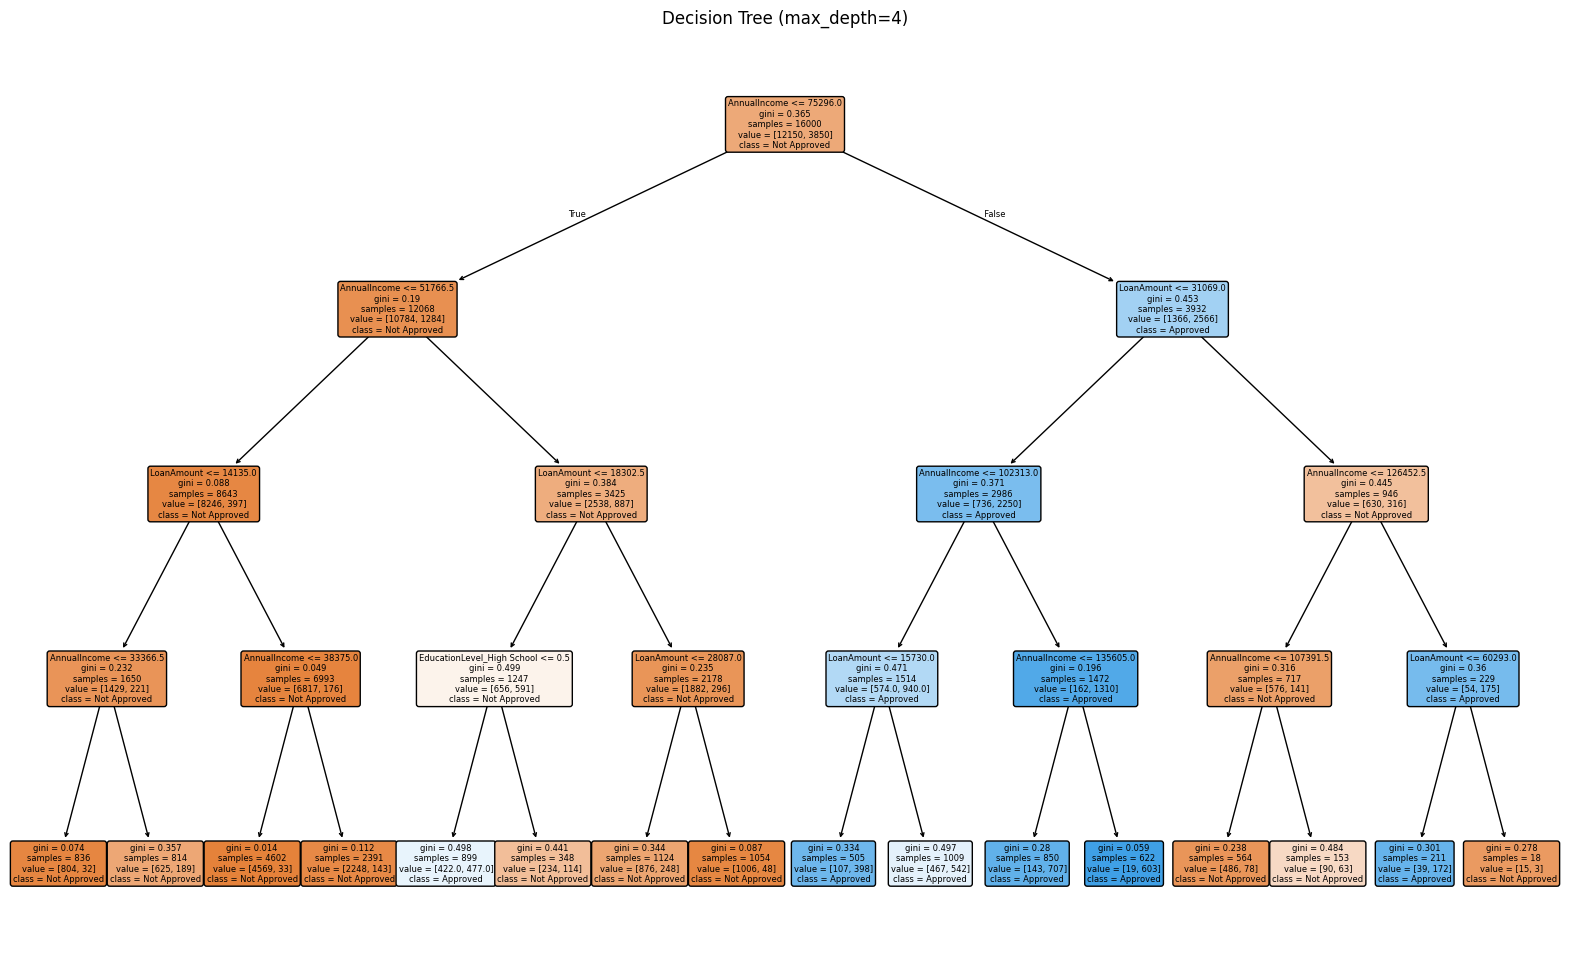

In [50]:
# ------------------- VISUALIZE DECISION TREE -------------------
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))

plot_tree(
    dt_small,
    feature_names=X_encoded.columns,
    class_names=["Not Approved", "Approved"],
    filled=True,
    rounded=True,
    fontsize=6
)

plt.title("Decision Tree (max_depth=4)")
plt.show()


If an applicant earns more than 102,313 per year and is requesting a loan amount of 15,730 or less, the decision tree predicts that their loan will be approved. The tree splits mainly on high-impact financial features such as AnnualIncome, LoanAmount, and Monthly_Debt_To_Income_Ratio. These features appear early in the tree because they strongly influence approval decisions. Later splits involve employment status and marital status, which refine the decision for borderline applicants. This shows that the model prioritizes financial capacity before demographic attributes.


## Data Preparation for Modelling


In [104]:
# Drop columns that should NOT be used in prediction:
#    ApplicationNumber is a unique ID and does not affect the loan approval outcome.
df_model = df.drop("ApplicationNumber", axis=1)

I dropped the applicationNumber column because it is a unique identifier and contains no information that affects the loan approval decision. Keeping ID-like columns harms the model by adding noise.

The ApplicationNumber column is removed because unique IDs do not affect approval outcomes. Keeping an ID column can mislead the model by adding random noise, so dropping it improves model quality.

In [105]:
# Separate features (X) and target (y)
# -----------------------------

# LoanApproved is the target variable (0 = No, 1 = Yes)
y = df_model["LoanApproved"]

# X will contain all columns EXCEPT the target
X = df_model.drop("LoanApproved", axis=1)

In [106]:
# Identify categorical and numerical columns

# Decision Trees can handle numerical data directly,
# but categorical variables MUST be encoded into numerical format.
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

In [107]:
# One-Hot Encoding for categorical variables

# We use ONE-HOT ENCODING  because:
# - These categories are nominal (no natural order)
# - Decision trees do NOT require normalization after encoding
# - drop_first=False is fine because trees are not affected by dummy variable trap

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

We use One-Hot Encoding because all our categorical variables are nominal, meaning they have no inherent order (e.g., Married ≠ greater than Single).
Decision Trees also do not require feature scaling after encoding, so this is the correct and efficient encoding option.

Unlike K-Means or Linear Regression, Decision Trees are not affected by different scales.
Trees split based on thresholds (e.g., Income > 50,000), so normalization is unnecessary.

Categorical variables are converted into binary columns because machine learning models require numeric inputs. One-hot encoding is appropriate since these features have no natural order (e.g., Rent ≠ Own ≠ Other). Decision trees are not affected by scaling, so this encoding works perfectly.

## Modelling

In [108]:
# ------------------- TRAIN–TEST SPLIT -------------------

from sklearn.model_selection import train_test_split

# X_encoded contains all features ready for training
# y contains the target variable (0/1)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,      # 80% training, 20% testing (same ratio used in labs)
    random_state=42     # ensures reproducibility
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


Training set size: 16000
Testing set size: 4000


We split the data so the model trains on one portion and is evaluated on unseen data, allowing us to measure how well the model generalizes.

The dataset is split so that the model learns from 80% of the data and is evaluated on the remaining 20%. This helps measure how well the model performs on new, unseen applicants and prevents overfitting.

In [109]:
# ------------------- DECISION TREE MODEL -------------------

from sklearn.tree import DecisionTreeClassifier

# Initialize model with default settings
# Criterion="gini" is the default and was used in Lab 6
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

we did decision tree classifier because this is a binary classification problem (approve / not approve), and decision trees handle:
mixed data types, non-linear thresholds, high-dimensional encoded features,which fits this dataset perfectly.

A decision tree is used because the target is binary (approve/not approve) and the features include mixed data types. Decision trees can capture non-linear patterns, thresholds, and interactions between financial and demographic features. The trained tree shows meaningful splits that align with real loan decision logic.

## Evaluation

In [110]:
# ------------------- CHECK CLASS BALANCE -------------------
class_counts = y.value_counts()
print("Class Distribution:\n", class_counts)

# Calculate imbalance ratio
imbalance_ratio = class_counts.min() / class_counts.max()
print("Imbalance Ratio:", imbalance_ratio)

Class Distribution:
 LoanApproved
0    15220
1     4780
Name: count, dtype: int64
Imbalance Ratio: 0.3140604467805519


Because the imbalance ratio is 0.31, the dataset is imbalanced.Because the dataset is imbalanced, accuracy is not a reliable metric, so precision, recall and especially the F1-score are more suitable for evaluating the model’s performance. This means accuracy is not enough, so precision, recall, and F1-score give a much more reliable evaluation of the model’s performance on the minority class (approved loans).

The counts show that only about 31% of applicants are approved, meaning the dataset is imbalanced. Because of this, accuracy alone is misleading. Precision, recall, and F1-score are needed to evaluate how well the model handles the smaller approved-loan class.

In [111]:
# ------------------- MODEL EVALUATION: PRECISION -------------------
from sklearn.metrics import precision_score

# Generate predictions (must be done before precision)
y_pred = dt.predict(X_test)

# Precision focuses on the positive class (1 = Approved)
precision = precision_score(y_test, y_pred)

print("Precision Score (Approved loans):", precision)


Precision Score (Approved loans): 0.6286008230452675


Precision focuses only on the positive class (1 = Approved). It shows how many applicants predicted as “Approved” actually deserved approval. A precision of 0.636 means that when the model approves someone, it is correct about 63% of the time. This metric is important in banking because false approvals can create financial losses. High precision means the model is careful when approving applicants.

Precision measures how many predicted “Approved” cases are actually correct. A precision of ~0.63 means the model is cautious: when it approves someone, it is right about 63% of the time. This is important in banking because approving risky applicants leads to financial loss.

In [112]:
# ------------------- MODEL EVALUATION: RECALL -------------------
from sklearn.metrics import recall_score

# Recall for approved loans (class = 1)
recall = recall_score(y_test, y_pred)

print("Recall Score (Approved loans):", recall)


Recall Score (Approved loans): 0.656989247311828


The recall score of 0.6537 means that the model correctly identified about 65% of all applicants who were actually approved.

Recall focuses on capturing the true approved cases, so a higher recall means the model is less likely to miss applicants who should be approved. This is important in loan approval because low recall would mean many eligible applicants are wrongly rejected, which is undesirable from both a business and customer fairness perspective.

Recall measures how many of the true approved applicants the model successfully identifies. A recall of ~0.66 means it captures about two-thirds of all eligible applicants. A low recall would mean many qualified people are unfairly rejected, so this score is important for fairness and customer satisfaction.

In [113]:
# ------------------- MODEL EVALUATION: F1-SCORE -------------------
from sklearn.metrics import f1_score

# F1 Score for positive class (approved)
f1 = f1_score(y_test, y_pred)

print("F1 Score (Approved loans):", f1)


F1 Score (Approved loans): 0.6424815983175605


The F1 score of 0.645 shows a balanced performance between precision and recall for approved loans. It means the model is moderately good at both correctly approving applicants and not missing too many who should be approved. It confirms that the model handles the positive class reasonably well but still has room for improvement. Because the dataset is imbalanced, accuracy is not reliable. The F1-score is the most appropriate evaluation metric since it balances precision and recall for the minority class (approved loans).

The F1-score (~0.64) balances precision and recall. This metric is most suitable for imbalanced data. The score shows that the model performs moderately well on the approved class but still has room for improvement.

In [114]:
# ------------------- CLASSIFICATION REPORT -------------------

from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      3070
           1       0.63      0.66      0.64       930

    accuracy                           0.83      4000
   macro avg       0.76      0.77      0.77      4000
weighted avg       0.83      0.83      0.83      4000



The model performs very well on class 0 with high precision, recall, and F1-score (0.89). Performance on class 1 is lower (around 0.64–0.65), meaning the model is less consistent at identifying approved loans. Overall accuracy is strong (0.83), but the gap between the two classes shows that detecting approved applicants is more challenging for the model.

The report shows that class 0 (not approved) has high performance (precision/recall ~0.89), while class 1 has lower values (~0.64). This confirms that the model is much better at detecting non-approved loans, which is expected due to the class imbalance.

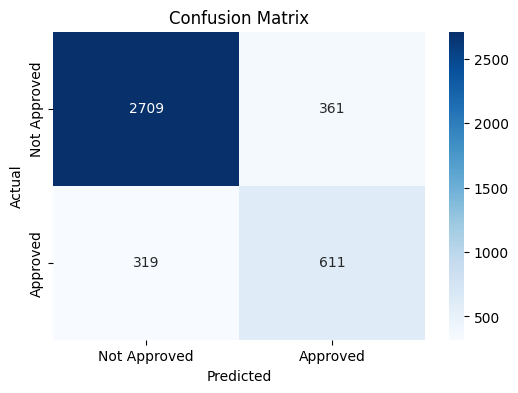

In [115]:
# ------------------- CONFUSION MATRIX -------------------

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Approved", "Approved"],
            yticklabels=["Not Approved", "Approved"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


The confusion matrix shows that most negative cases (class 0) are correctly predicted, while the model still misses some approved applicants (class 1). This means the model is better at detecting non-approved loans than approved ones.

The matrix shows many true negatives, a good number of true positives, but also some false negatives. This means the model misses some approved applicants. The imbalance makes detecting class 1 more difficult, which explains the weaker performance on approved loans.

## Bonus (Optional)

In [117]:
# BONUS – APPLY A DIFFERENT CLASSIFICATION MODEL (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

# Initialize logistic regression with higher iterations and a robust solver
log_reg = LogisticRegression(max_iter=5000, solver='liblinear')

# Train the model
log_reg.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test)

# Evaluate logistic regression
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Performance:")
print("Precision:", round(prec_lr, 4))
print("Recall:", round(rec_lr, 4))
print("F1-Score:", round(f1_lr, 4))




Logistic Regression Performance:
Precision: 0.7899
Recall: 0.671
F1-Score: 0.7256


Because the dataset is imbalanced, the F1-score is the most appropriate evaluation metric. Logistic Regression achieves a noticeably higher F1-score (0.7256) compared to the Decision Tree (0.6451), meaning it provides a better balance between correctly detecting approved applicants and avoiding false approvals. Logistic Regression also has higher precision and recall, showing more reliable performance overall. Therefore, Logistic Regression is the recommended model for this dataset.

Logistic Regression is used to compare performance with the decision tree. Its F1-score (~0.73) is higher, meaning it is better at balancing precision and recall for approved loans. Because the dataset is imbalanced, this makes Logistic Regression the stronger model. Its better recall shows it finds more eligible applicants without causing too many false approvals.